# **SM2ST Automatic Registration**

In [1]:
# import my_package.rectification as rectification
msi_file="/home/llx/project/MSI_data/sma/V11T16-085/V11T16-085_B1/output_data/V11T16-085_B1_MSI/V11T17-085_B1.Visium.FMP.220826_smamsi.csv"
st_path="/home/llx/project/MSI_data/sma/V11T16-085/V11T16-085_B1/output_data/V11T16-085_B1_RNA/outs/"
msi_path="/home/llx/project/MSI_data/sma/V11T16-085/V11T16-085_B1/output_data/V11T16-085_B1_MSI/"
import importlib
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
from SM2ST import rectification

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **1 Multimodal image registration**

86 87


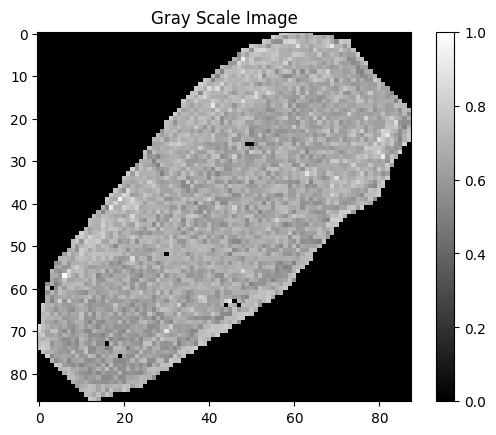

In [2]:
ms_org=pd.read_csv(msi_file)
ms_sp=ms_org.copy()
print(np.max(ms_sp.loc[:,"x"]),np.max(ms_sp.loc[:,"y"]))
ms=rectification.msi_sum(ms_sp,0.5)
rectification.tensor_viewer(ms)

### **1.1 Feature selection**

In [3]:
# # feature_columns = ms_n.columns[2:]
ms_sp_c=ms_org.copy()
non_zero_counts = ms_sp_c.iloc[:, 2:].gt(0).sum(axis=1)
# Organization boundary management
mask = non_zero_counts >= 1300
# Use boolean masks to assign values to the rows that meet the conditions
ms_sp_c.loc[mask, ms_sp_c.columns[2:]] = 0.0

ms_sp_c

,x,y,156.26059,156.26195,156.48344,156.4838,156.485,157.54681,158.41217,160.02547,...,1044.29885,1044.3523,1046.31366,1046.32671,1046.33977,1046.36442,1048.32025,1048.3319,1048.34354,1048.38431
0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7651,86,83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7652,86,84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7653,86,85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7654,86,86,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Calculate the sum of each row (starting from the third column)
row_sums = ms_sp_c.iloc[:,2:].sum(axis=1)

# 删除总和为0的行
ms_n = ms_sp_c[row_sums >= 1e6]

In [5]:
ms_n

,x,y,156.26059,156.26195,156.48344,156.4838,156.485,157.54681,158.41217,160.02547,...,1044.29885,1044.3523,1046.31366,1046.32671,1046.33977,1046.36442,1048.32025,1048.3319,1048.34354,1048.38431
57,0,57,15388.106445,12699.410156,6918.613281,52462.691406,0.000000,3546.275879,83495.976562,0.0,...,0.000000,1373.387329,1.506270e+05,41455.714844,42552.917969,1.336460e+06,70575.132812,26976.490234,8931.179688,14486.295898
58,0,58,399832.750000,247249.937500,32002.357422,8288.413086,10239.052734,0.000000,11785.220703,0.0,...,0.000000,0.000000,8.707337e+04,53729.781250,43629.769531,8.346074e+05,30440.119141,21167.244141,27214.576172,0.000000
60,0,60,342339.500000,9803.553711,119597.773438,139355.312500,4924.487793,11153.581055,168960.062500,0.0,...,23189.890625,13950.716797,1.827716e+06,122682.359375,45033.027344,1.413450e+06,717320.062500,61187.546875,0.000000,82515.078125
63,0,63,131707.812500,2730.252930,27889.546875,0.000000,0.000000,28752.599609,186354.109375,0.0,...,0.000000,0.000000,7.918688e+05,611359.812500,8074.065430,1.703040e+06,433445.468750,508865.593750,42733.503906,403173.281250
146,1,58,214072.421875,19027.863281,74756.171875,15447.994141,0.000000,0.000000,128170.367188,0.0,...,0.000000,0.000000,8.079220e+05,407129.000000,19553.447266,9.740408e+05,435747.156250,220896.500000,0.000000,181954.421875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,85,16,30188.523438,8018.304688,8127.230469,137116.296875,5972.976562,7247.633789,121351.656250,0.0,...,0.000000,12254.841797,4.465621e+05,38825.398438,19290.261719,1.058845e+06,144980.546875,10613.855469,0.000000,31178.644531
7497,85,17,247360.156250,0.000000,107201.046875,35873.441406,0.000000,20104.916016,174298.796875,0.0,...,23348.113281,28221.925781,1.416684e+06,329348.812500,46931.843750,1.360872e+06,639293.312500,348172.187500,0.000000,213297.703125
7580,86,12,71832.906250,6480.308594,6467.060059,148183.218750,0.000000,10585.411133,121719.492188,0.0,...,0.000000,8281.744141,6.976806e+05,35699.761719,17340.201172,1.110201e+06,257564.546875,16210.779297,20490.242188,46144.125000
7581,86,13,29056.251953,119.364128,7820.826172,117947.187500,7652.152344,10160.342773,118123.875000,0.0,...,0.000000,0.000000,3.747150e+05,40482.437500,23978.386719,9.447358e+05,122394.156250,14329.344727,0.000000,32985.386719


In [6]:
from scipy.sparse import csr_matrix, csc_matrix, coo_matrix
ms_intensity = csr_matrix(ms_n.iloc[:,2:], dtype=np.float32)
print(ms_intensity.shape)
ms_adata = ad.AnnData(ms_intensity)
ms_adata.obs["array_row"]=ms_n.iloc[:,0] ##raw x
ms_adata.obs["array_col"]=ms_n.iloc[:,1] ##raw y
ms_adata.var_names=ms_n.iloc[:,2:].columns
ms_adata.obsm["spatial"]=ms_n.loc[:,["x","y"]].to_numpy()
# ms_adata.obs_names=ms_n.index

(2608, 1538)


In [7]:
ms_adata

AnnData object with n_obs × n_vars = 2608 × 1538
    obs: 'array_row', 'array_col'
    obsm: 'spatial'

In [8]:
import squidpy as sq
sq.gr.spatial_neighbors(ms_adata)
sq.gr.spatial_autocorr(ms_adata, mode="moran", genes=ms_adata.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [9]:
high_moran_genes2 = ms_adata.uns['moranI']['I'][(ms_adata.uns['moranI']['I'] > 0.5) & (ms_adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_high_moran2 = ms_adata[:, high_moran_genes2]
adata_high_moran2

View of AnnData object with n_obs × n_vars = 2608 × 199
    obs: 'array_row', 'array_col'
    uns: 'spatial_neighbors', 'moranI'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [10]:
adata_high_moran2.var_names

Index(['674.2805', '675.28296', '444.20715', '690.27454', '445.21078',
       '711.31089', '957.37883', '170.45622', '353.1652', '711.24789',
       ...
       '537.22442', '438.01315', '622.29085', '861.34823', '289.12287',
       '368.17603', '408.12338', '862.09285', '351.14952', '553.2313'],
      dtype='object', length=199)

In [11]:
import scanpy as sc
sc.pp.highly_variable_genes(ms_adata, flavor="seurat_v3", n_top_genes=100)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [12]:
columns_to_sum = ms_adata[:, ms_adata.var['highly_variable']].var_names

In [13]:
def standard(vec_1):
    return (vec_1-min(vec_1))/(max(vec_1)-min(vec_1))

def msi_sum(ms, threshold, columns_to_sum):
    """
    Sum the specified columns and generate a standardized matrix 
    Parameters:
    ms -- A DataFrame containing x and y coordinates as well as multiple columns of data
    threshold -- The threshold for the standardized values, values below this threshold will be set to 0
    columns_to_sum -- A list of column names to be summed up 
    Return:
    ms_sum -- The matrix after normalization and applying the threshold
    """
    # Select specific columns for summation
    if columns_to_sum is None:
        # If no specific column is specified, then the sum will be calculated for all columns.
        ms_n = pd.concat([ms.loc[:, ["x", "y"]], ms.iloc[:, 2:].sum(axis=1)], axis=1)
    else:
        # If columns are specified, the summation will only be performed on those columns.
        ms_n = pd.concat([ms.loc[:, ["x", "y"]], ms[columns_to_sum].sum(axis=1)], axis=1)

    ms_n.columns = ["x", "y", "sum"]

    # Standardize the summed values
    ms_n.loc[:, "sum_standard"] = standard(ms_n.loc[:, "sum"])

    # Build Matrix
    ms_sum_matrix = ms_n.pivot(index='x', columns='y', values="sum_standard")

    # Application Threshold
    ms_sum = np.where(ms_sum_matrix < threshold, 0, ms_sum_matrix)

    return ms_sum

86 87


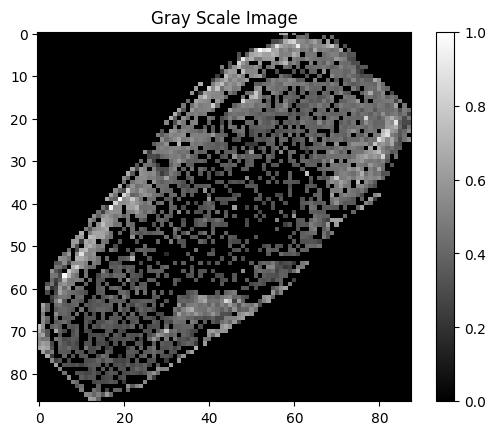

In [14]:
# ms_org=pd.read_csv(msi_file)
# ms_sp=ms_org.copy()
print(np.max(ms_sp_c.loc[:,"x"]),np.max(ms_sp_c.loc[:,"y"]))
ms=msi_sum(ms_sp_c,0.,adata_high_moran2.var_names)
rectification.tensor_viewer(ms)

### **1.2 Affine transformation**

In [15]:
from PIL import Image

ms_uint8 = (ms * 255).astype(np.uint8)
img_ms = Image.fromarray(ms_uint8, mode='L')
# img_ms.save('output_ms_41.png')

In [16]:
org_size=ms.shape
org_size

(87, 88)

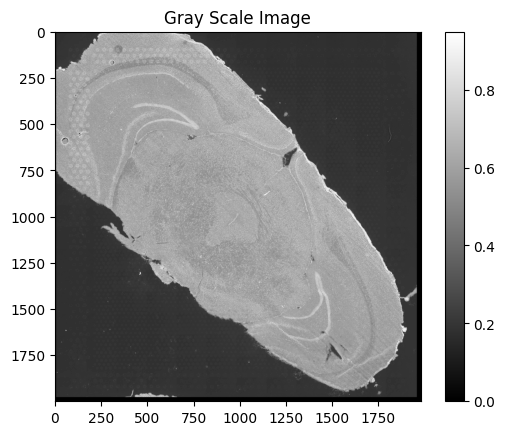

In [17]:
image_path = '/home/llx/project/MSI_data/sma/V11T16-085/V11T16-085_B1/output_data/V11T16-085_B1_RNA/outs/spatial/tissue_hires_image.png'

normalized_gray_image=rectification.he_img(image_path)
rectification.tensor_viewer(normalized_gray_image)

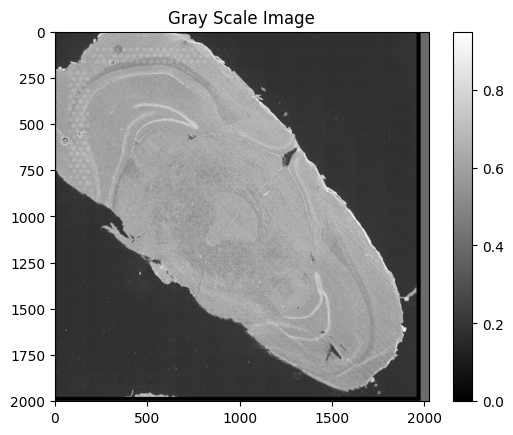

In [18]:
HE_tensor,msi_tensor,rate=rectification.he_padding(ms,normalized_gray_image,0.4)#填充到与MSI等比例
rectification.tensor_viewer(HE_tensor)

In [19]:
target_size=np.array(HE_tensor.shape[2:4])
target_size

array([2001, 2024])

In [20]:
device=torch.device("cuda")

In [21]:
fit_af=rectification.fit(device=device,num_epochs=1000)
fit_af.train_AF(msi_tensor,HE_tensor,list(target_size))#训练

  0%|                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/torch/nn/functional.py:4227: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 494.31it/s]


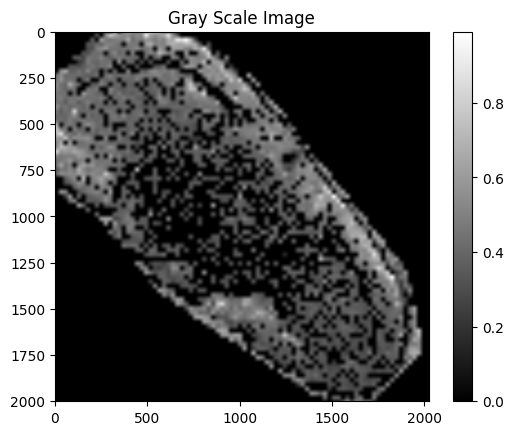

torch.Size([1, 1, 2001, 2024])


In [22]:
af_msi=fit_af.net(msi_tensor.to(device))
rectification.tensor_viewer(af_msi.cpu().detach())
print(af_msi.shape)

In [23]:
af_theta=fit_af.net.theta.squeeze().cpu().detach()
print(af_theta)

tensor([[-0.9500,  0.0000, -0.0893],
        [ 0.0000,  0.9500,  0.0088]])


In [24]:
ms_org_x_y = torch.tensor(np.array(ms_sp.loc[:,["y","x"]]),dtype=torch.float32)

ms_he = rectification.torch_af_transfor(af_theta,target_size,org_size,ms_org_x_y)

ms_he

tensor([[1982.1458,  -61.9267],
        [1957.9357,  -61.9267],
        [1933.7257,  -61.9267],
        ...,
        [ -75.7048, 2020.1338],
        [ -99.9150, 2020.1338],
        [-124.1250, 2020.1338]])

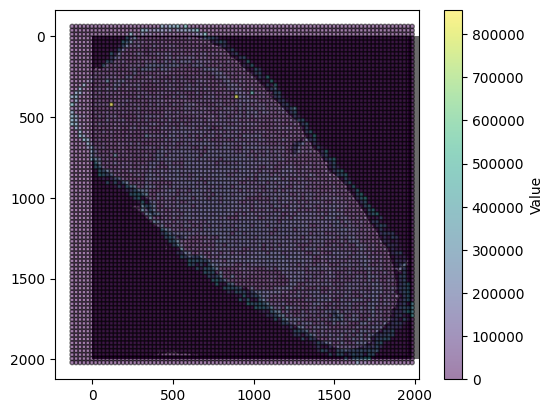

In [25]:
ms_sp.loc[:,["he_x","he_y"]]=ms_he.numpy()
plt.imshow(HE_tensor.squeeze().detach().cpu(), cmap='gray')
scatter = plt.scatter(ms_sp['he_x'], 
                    ms_sp['he_y'], 
                    c=ms_sp['156.26059'], 
                    cmap='viridis', 
                    s=10,
                    alpha=0.5,
                    edgecolor='k')

plt.colorbar(scatter, label='Value')

### **1.3 Calculate the error of the landmark**

In [26]:
import SM2ST
ms_adata = SM2ST.ms2anndata(ms_org = ms_org,ms_sp = ms_sp,HE_path = image_path,in_tissue=True)

In [27]:
import scanpy as sc
st_adata=sc.read_visium(st_path,
               count_file='filtered_feature_bc_matrix.h5',
               source_image_path="tissue_hires_image.png")
st_adata

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3357 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [28]:
st_adata_spatialmeta=sc.read_h5ad('/home/llx/project/jupyternotebook/085B1_spatialmeta.h5ad')

In [30]:
obs_index = list(np.loadtxt('../points_msi_index_41.txt', dtype=int)) #[364,3613,2598,2622,3778]
st_adata_spatialmeta.uns["landmark_index"]=obs_index
pred=st_adata_spatialmeta.obsm['spatial_transformed'][obs_index,:]

In [33]:
# coords = st_adata.obsm['spatial'][15:20]*st_adata.uns['spatial']['V11T16-085_B1']['scalefactors']['tissue_hires_scalef']
# Read txt (default separated by spaces or tabs)
or_point = np.loadtxt('../points_HE_41.txt')

# Convert to PyTorch Tensor (if you need a tensor)
or_point_tensor = torch.from_numpy(or_point).float()

print("Shape:", or_point.shape)
print("Data:\n", or_point)

Shape: (5, 2)
Data:
 [[ 494.  220.]
 [1058. 1585.]
 [1023. 1144.]
 [ 444. 1143.]
 [1480. 1691.]]


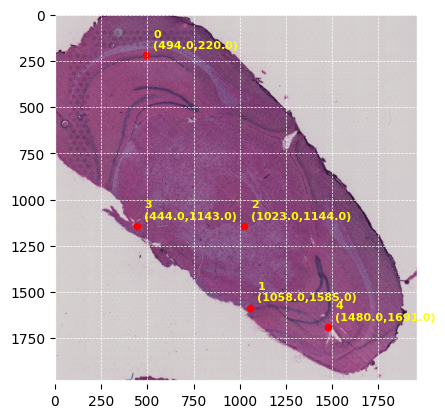

In [34]:
coords = or_point
plt.imshow(st_adata.uns['spatial']['V11T16-085_B1']['images']['hires'])
# Add white grid lines
plt.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=1)

# Hide axis scale (keep grid lines)
# ax.set_xticks([]) 
# ax.set_yticks([])

ax = plt.gca()  # Obtain the current axes
for spine in ax.spines.values():
    spine.set_visible(False)
# plt.axis('off')  # Hide the horizontal and vertical coordinate axes
plt.scatter(coords[:,0], coords[:,1], c='red', s=20)
for i, (x, y) in enumerate(coords):
    plt.annotate(f'{i}\n({x:.1f},{y:.1f})', 
                xy=(x, y), xytext=(5, 5), 
                textcoords='offset points',
                color='yellow', fontsize=8,fontweight='bold')
# plt.savefig('output.png')

In [39]:
msi_point = np.loadtxt('../points_MSI_41.txt')
msi_point_tensor = torch.from_numpy(msi_point).float()

print("Shape:", msi_point.shape)
print("Data:\n", msi_point)

Shape: (5, 2)
Data:
 [[61. 12.]
 [38. 68.]
 [40. 50.]
 [64. 50.]
 [21. 72.]]


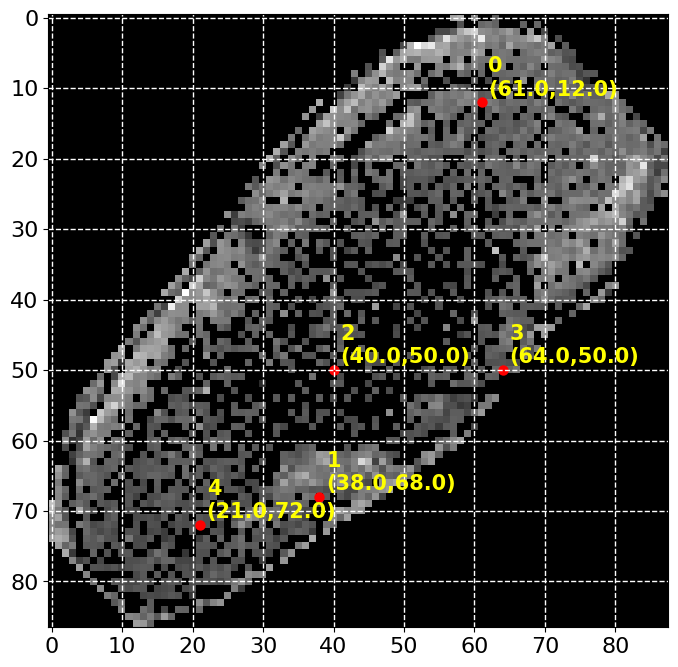

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import torch

points = msi_point_tensor
# print(points_int)

if isinstance(points, torch.Tensor):
    points_np = points.cpu().numpy()
else:
    points_np = np.array(points)

# 创建图像
plt.figure(figsize=(8, 8))
plt.imshow(ms_uint8, cmap='gray', vmin=0, vmax=255)
plt.grid(True, color='white', linestyle='--', linewidth=1, alpha=1)
# Draw points
# Note: If points are in the format of [x, y] (column, row), simply use scatter
# If in the format of [y, x], then use points_np[:, [1, 0]]
plt.scatter(points_np[:, 0], points_np[:, 1], 
           c='red',           # 红色
           s=30,             # 点大小
           marker='o',        # 圆形
           # edgecolors='white', # 白边更清晰
           linewidths=2,
           label='Key Points')#

# Add coordinate labels (optional)
for i, (x, y) in enumerate(points_np):
    plt.annotate(f'{i}\n({x:.1f},{y:.1f})', 
                xy=(x, y), xytext=(5, 5), 
                textcoords='offset points',
                color='yellow', fontsize=15,fontweight='bold')

# plt.title('Points on MS Image')
# plt.axis('off')  
# plt.legend()
# plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [41]:
re_point_tensor = rectification.torch_af_transfor(af_theta,target_size,org_size,msi_point_tensor)
re_point_tensor

tensor([[ 505.3353,  228.5934],
        [1062.1654, 1584.3536],
        [1013.7453, 1148.5736],
        [ 432.7052, 1148.5736],
        [1473.7355, 1681.1938]])

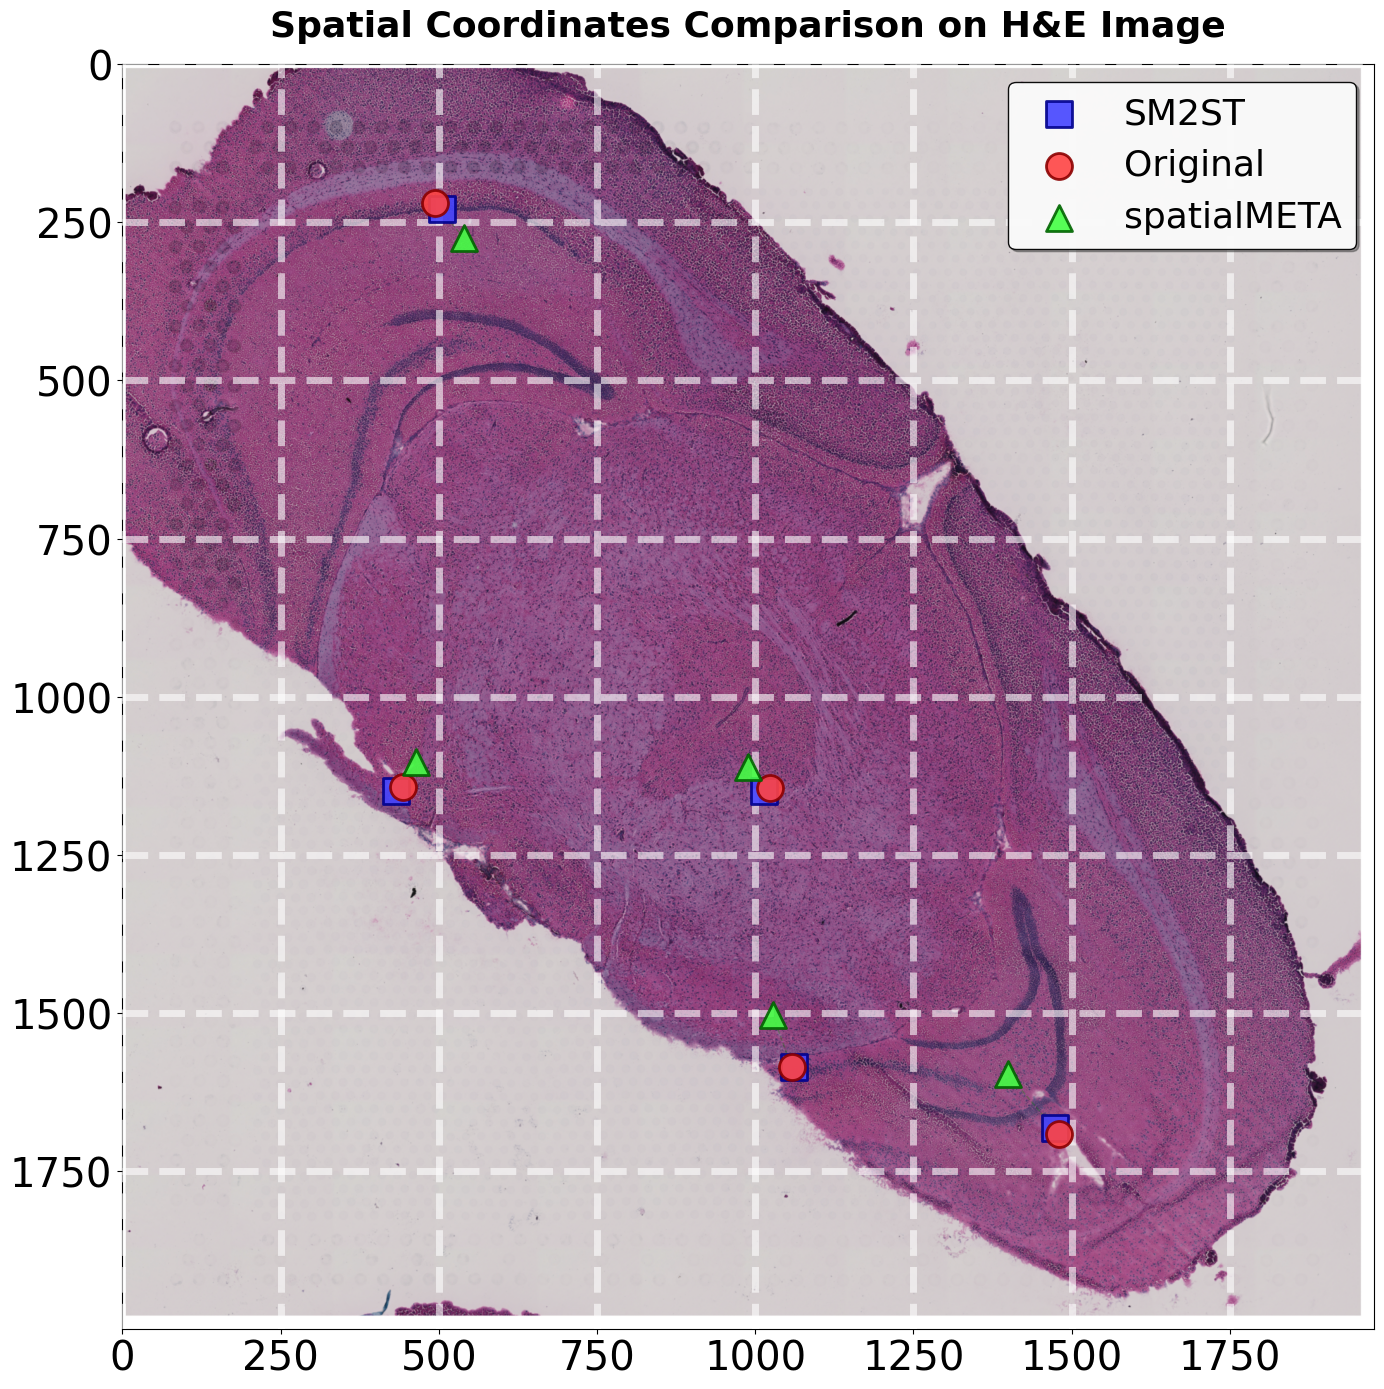

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==================== Data Preparation ====================

# 1. Load hires images
hires_img = st_adata.uns['spatial']['V11T16-085_B1']['images']['hires']

# 2. re_point_tensor 转为 numpy array (SM2ST)
# Assume that re_point_tensor is a torch tensor or already an array
if isinstance(re_point_tensor, torch.Tensor):
    re_point_array = re_point_tensor.detach().cpu().numpy()
else:
    re_point_array = np.array(re_point_tensor)

# 3. coords - Original Coordinates
# Assume that coords is your original coordinate array 
# 4. pred - spatialMETA Prediction Coordinates
# Assume that pred is your array of predicted coordinates

# ==================== Drawing ====================

fig, ax = plt.subplots(1, 1, figsize=(16, 14))

ax.imshow(hires_img)

# SM2ST (re_point_tensor/array) - Blue square
ax.scatter(re_point_array[:, 0], re_point_array[:, 1], 
          c='#4444FF', s=350, marker='s', alpha=0.9, 
          edgecolors='darkblue', linewidths=2,
          label='SM2ST', zorder=5)

# Original (coords) - Red circle
ax.scatter(coords[:, 0], coords[:, 1], 
          c='#FF4444', s=350, marker='o', alpha=0.9, 
          edgecolors='darkred', linewidths=2,
          label='Original', zorder=5)

# spatialMETA (pred) - Green triangle
ax.scatter(pred[:, 0], pred[:, 1], 
          c='#44FF44', s=350, marker='^', alpha=0.9, 
          edgecolors='darkgreen', linewidths=2,
          label='spatialMETA', zorder=5)

# Add grid lines
ax.grid(True, linestyle='--', alpha=0.6, color='white', linewidth=5.0)
ax.set_axisbelow(False)  # The grid lines are above the scattered points.

# Add grid lines
ax.set_title('Spatial Coordinates Comparison on H&E Image', 
             fontsize=26, fontweight='bold', pad=20)
# ax.set_xlabel('X coordinate (pixels)', fontsize=13)
# ax.set_ylabel('Y coordinate (pixels)', fontsize=13)

# Add legend
ax.legend(loc='best', fontsize=26, framealpha=0.95, 
          edgecolor='black', fancybox=True, shadow=True)

# Optional: Add connection lines to show the corresponding relationship
for i in range(min(len(re_point_array), len(coords), len(pred))):
    # Connect SM2ST and Original
    ax.plot([re_point_array[i, 0], coords[i, 0]], 
            [re_point_array[i, 1], coords[i, 1]], 
            'r--', alpha=0.3, linewidth=1)
    # Connect spatialMETA and Original
    ax.plot([pred[i, 0], coords[i, 0]], 
            [pred[i, 1], coords[i, 1]], 
            'g--', alpha=0.3, linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=29)
plt.tight_layout()
# plt.savefig('/home/llx/project/jupyternotebook/spatial_comparison_41.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
diff = or_point_tensor - re_point_tensor  # [N, 2]
rmse_per_point = torch.sqrt((diff ** 2).mean(dim=1))  # √[(dx²+dy²)/2]

squared = diff ** 2           # dx², dy²
mse = squared.mean(dim=1)     # (dx²+dy²)/2
rmse = torch.sqrt(mse)        # √MSE

total_rmse = torch.sqrt((diff ** 2).mean())  
print(f"Overall RMSE: {total_rmse.item():.6f}")
print(f"Each point RMSE:\n{rmse_per_point}")
mae_per_point = torch.mean(torch.abs(or_point_tensor - re_point_tensor), dim=1)  
total_mae = torch.mean(mae_per_point)                    
print(f"Overall MAE: {total_mae.item():.6f}")
print(f"Each point MAE:\n{mae_per_point}")

Overall RMSE: 7.878544
Each point RMSE:
tensor([10.0582,  2.9806,  7.2996,  8.9061,  8.2282])
Overall MAE: 7.150790
Each point MAE:
tensor([9.9644, 2.4059, 6.9142, 8.4342, 8.0353])


In [44]:
import numpy as np
diff2 = or_point - pred  # [N, 2]  numpy array
# ==================== RMSE ====================

rmse_per_point2 = np.sqrt(np.mean(diff2 ** 2, axis=1))

squared2 = diff2 ** 2              
mse2 = np.mean(squared2, axis=1)    #  (dx²+dy²)/2
rmse2 = np.sqrt(mse2)               # 

total_rmse2 = np.sqrt(np.mean(diff2 ** 2))

# ==================== MAE ====================
mae_per_point2 = np.mean(np.abs(or_point - pred), axis=1)
total_mae2 = np.mean(mae_per_point2)

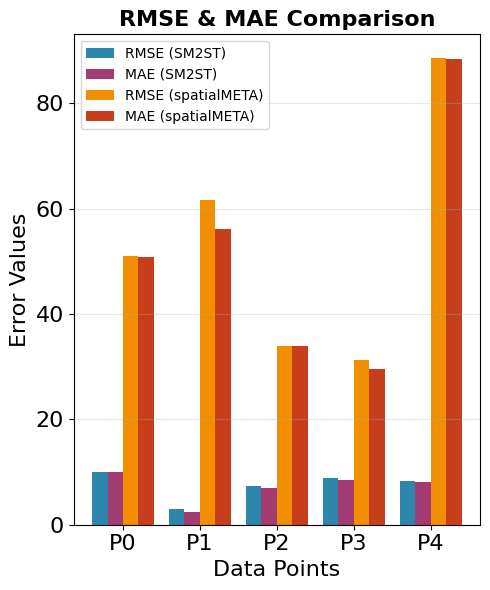

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# ================== data ==================
rmse_values = rmse_per_point    
mae_values = mae_per_point     
rmse_values2 = rmse_per_point2   
mae_values2 = mae_per_point2   
# =================================================

point_labels = ['P0', 'P1', 'P2', 'P3', 'P4']

fig, ax = plt.subplots(figsize=(5, 6))
x = np.arange(len(point_labels))
width = 0.2

# 四组并排柱状图
ax.bar(x - 1.5*width, rmse_values, width, label='RMSE (SM2ST)', color='#2E86AB')
ax.bar(x - 0.5*width, mae_values, width, label='MAE (SM2ST)', color='#A23B72')
ax.bar(x + 0.5*width, rmse_values2, width, label='RMSE (spatialMETA)', color='#F18F01')
ax.bar(x + 1.5*width, mae_values2, width, label='MAE (spatialMETA)', color='#C73E1D')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlabel('Data Points', fontsize=16)
ax.set_ylabel('Error Values', fontsize=16)
ax.set_title('RMSE & MAE Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(point_labels)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# st_adata.uns['spatial']['V11T16-085_B1']['scalefactors']['tissue_lowres_scalef']/st_adata.uns['spatial']['V11T16-085_B1']['scalefactors']['tissue_hires_scalef']

## **2 Mapping Metabolomic Information onto Transcriptomic Coordinates**

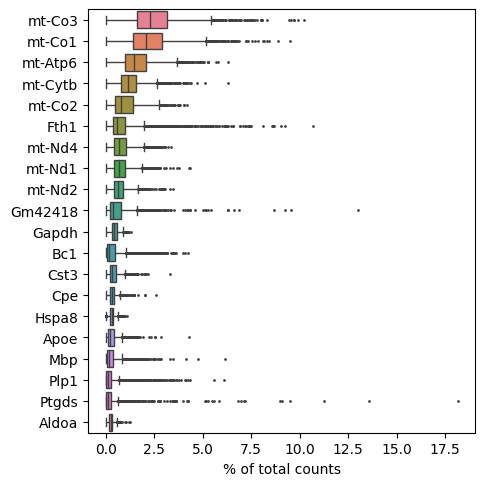

In [47]:
sc.pl.highest_expr_genes(st_adata, n_top=20)

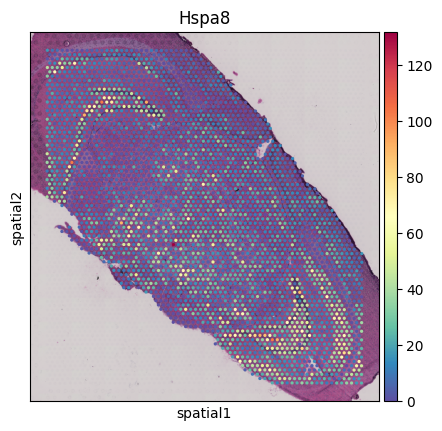

In [48]:
sc.pl.spatial(st_adata, 
              img_key="hires", 
              color=['Hspa8'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=1,
              spot_size=None,
              bw=False, 
              alpha_img=1)

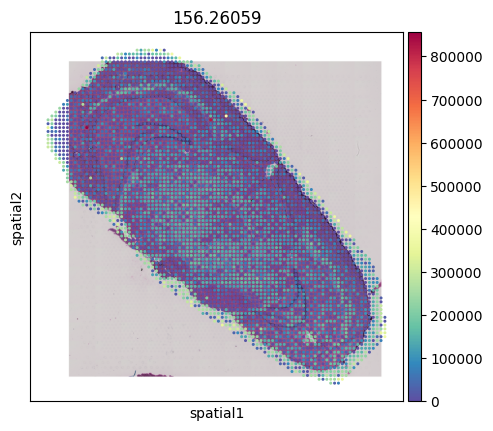

In [49]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['156.26059'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

In [50]:
st_intensity = csr_matrix(st_adata.X.A, dtype=np.float32)
print(st_intensity.shape)
st_adata1 = ad.AnnData(st_intensity)
st_adata1.var_names=st_adata.var_names
st_adata1.obs_names=st_adata.obs_names
st_adata1.obs["array_row"]=st_adata.obs["array_row"]##raw x
st_adata1.obs["array_col"]=st_adata.obs["array_col"]##raw y
st_adata1.obsm["spatial"]=st_adata.obsm["spatial"]*0.04155585
from PIL import Image
image_path = '/home/llx/project/MSI_data/sma/V11T16-085/V11T16-085_B1/output_data/V11T16-085_B1_RNA/outs/spatial/tissue_hires_image.png'
image = Image.open(image_path)
image_array = np.array(image)
spatial_key = "spatial"
library_id = "tV11L12-038_A1_c"  # 你可以自定义这个 ID
st_adata1.uns[spatial_key] = {library_id: {}}
st_adata1.uns[spatial_key][library_id]["images"] = {"hires": image_array}
st_adata1.uns[spatial_key][library_id]["scalefactors"] = {
    "tissue_hires_scalef": 1,  # The scaling factor between image pixels and spatial coordinates
    "spot_diameterres_full": 0.5,  # Diameter of each observation point
    'fiducial_diameter_fullres': 609.8565193216596,
    'spot_diameter_fullres': 377.5302262467417
}

(3357, 32285)


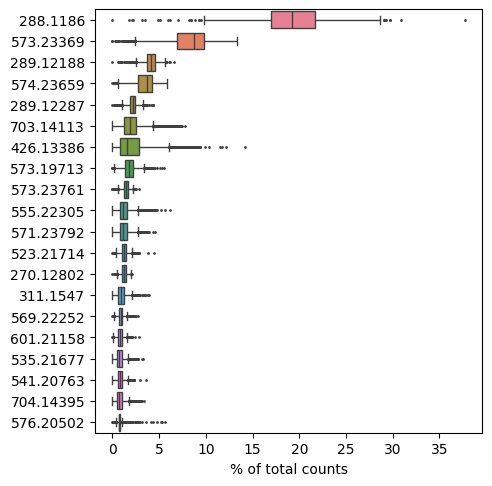

In [51]:
sc.pl.highest_expr_genes(ms_adata, n_top=20)

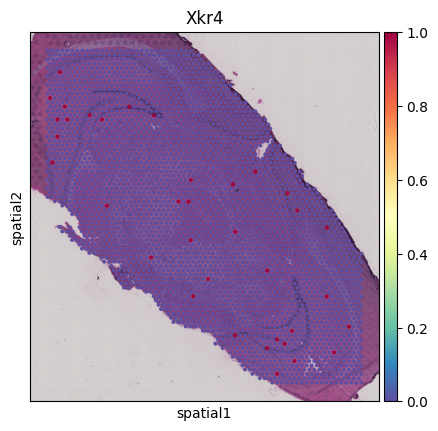

In [52]:
sc.pl.spatial(st_adata1, 
              img_key="hires", 
              color=['Xkr4'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

In [53]:
ms_adata.uns['coord'] = st_adata1.obsm['spatial']

<Axes: title={'center': '156.26059'}, xlabel='spatial1', ylabel='spatial2'>

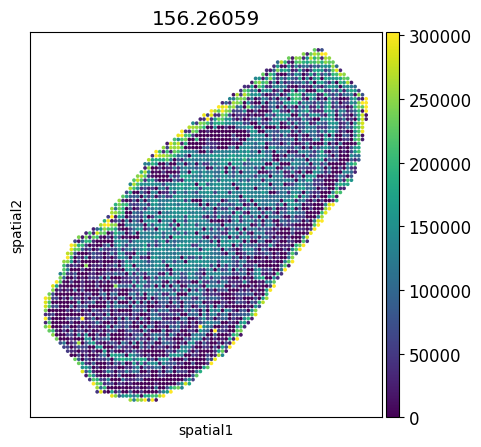

In [54]:
plot_gene = '156.26059'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12 
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [55]:
# sc.pp.normalize_total(ms_adata, target_sum=1e3)
sc.pp.normalize_total(ms_adata, target_sum=1e4)
sc.pp.log1p(ms_adata)

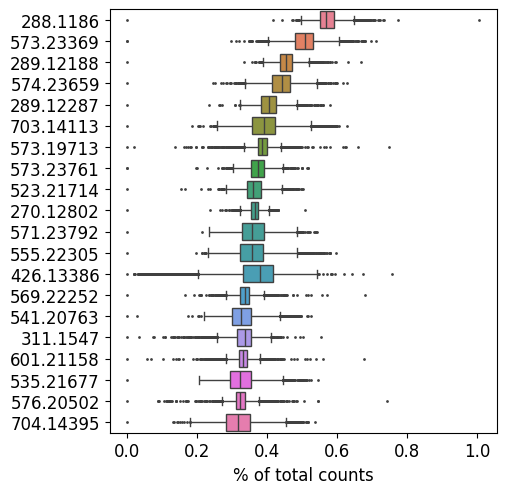

In [56]:
sc.pl.highest_expr_genes(ms_adata, n_top=20, )

<Axes: title={'center': '156.26059'}, xlabel='spatial1', ylabel='spatial2'>

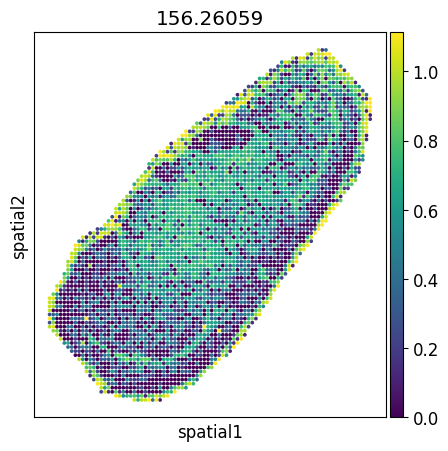

In [57]:
plot_gene = '156.26059'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

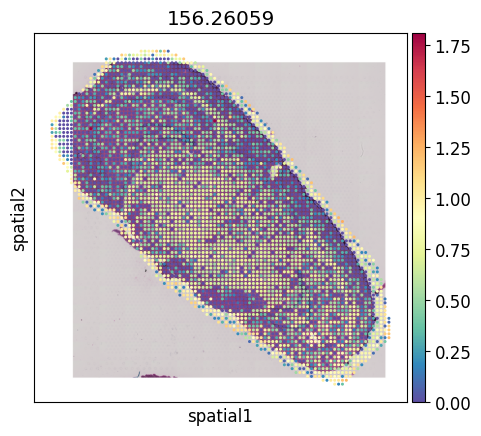

In [58]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['156.26059'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

In [59]:
import SM2ST as SM2ST
adata_SMLED = SM2ST.train_SMLED(adata=ms_adata, keep_ratio=0.5, coord_sf=2.0, train_epoch=10000, experiment='generation', mix_labels=False, WMMSE=1.)

<Axes: title={'center': '156.26059'}, xlabel='spatial1', ylabel='spatial2'>

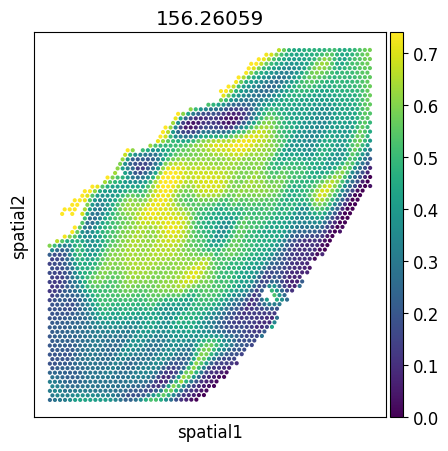

In [57]:
plot_gene = '156.26059'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

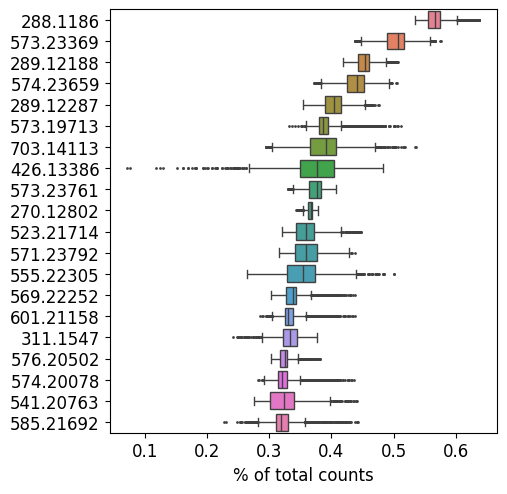

In [58]:
sc.pl.highest_expr_genes(adata_SMLED, n_top=20)

<Axes: title={'center': '573.23369'}, xlabel='spatial1', ylabel='spatial2'>

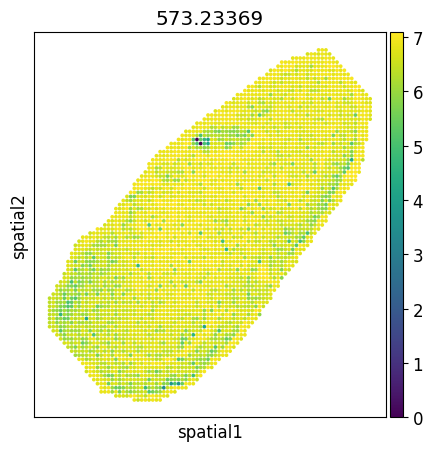

In [59]:
plot_gene = '573.23369'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(ms_adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '573.23369'}, xlabel='spatial1', ylabel='spatial2'>

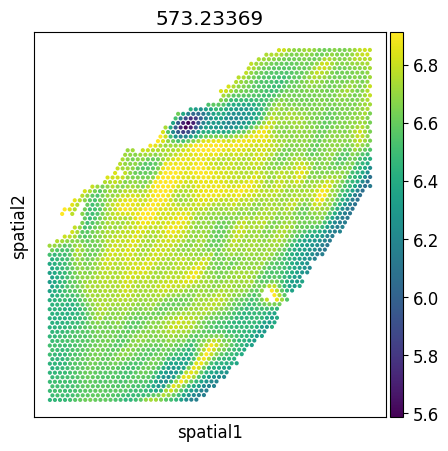

In [60]:
plot_gene = '573.23369'#
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [61]:
# st_intensity = csr_matrix(st_adata.X.A, dtype=np.float32)
# print(st_intensity.shape)
# st_adata1 = ad.AnnData(st_intensity)
# st_adata1.var_names=st_adata.var_names
# st_adata1.obs_names=st_adata.obs_names
# st_adata1.obs["array_row"]=st_adata.obs["array_row"]##raw x
# st_adata1.obs["array_col"]=st_adata.obs["array_col"]##raw y
# st_adata1.obsm["spatial"]=st_adata.obsm["spatial"]*0.04155585
from PIL import Image
image = Image.open(image_path)
image_array = np.array(image)
spatial_key = "spatial"
library_id = "V11T16-085_C1"  # 你可以自定义这个 ID
adata_SMLED.uns[spatial_key] = {library_id: {}}
adata_SMLED.uns[spatial_key][library_id]["images"] = {"hires": image_array}
adata_SMLED.uns[spatial_key][library_id]["scalefactors"] = {
    "tissue_hires_scalef": 1,  # 图像像素和空间坐标的比例因子
    "spot_diameterres_full": 0.5,  # 每个观测点的直径
    'fiducial_diameter_fullres': 609.8565193216596,
    'spot_diameter_fullres': 377.5302262467417
}

In [81]:
adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_SMLED_test_41_c1_wmse.h5ad')

In [73]:
adata_SMLED = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/adata_SMLED_test_41_c1_wmse.h5ad')

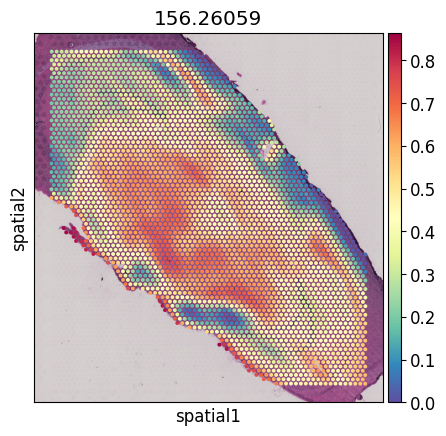

In [63]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['156.26059'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)#color是一个感兴趣的基因的list

### **2.1 Evaluate signal transfer**

In [64]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_SMLED)
sq.gr.spatial_autocorr(adata_SMLED, mode="moran", genes=adata_SMLED.var_names)
sq.gr.spatial_autocorr(adata_SMLED, mode="geary", genes=adata_SMLED.var_names)

In [65]:
import squidpy as sq
sq.gr.spatial_neighbors(ms_adata)
sq.gr.spatial_autocorr(ms_adata, mode="moran", genes=ms_adata.var_names)
sq.gr.spatial_autocorr(ms_adata, mode="geary", genes=ms_adata.var_names)

In [66]:
ms_adata_high_moran_genes = ms_adata.uns['moranI']['I'][(ms_adata.uns['moranI']['I'] > 0.15) & (ms_adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = ms_adata[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = ms_adata.uns['gearyC']['C'][(ms_adata.uns['gearyC']['C'] < 0.7) & (ms_adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = ms_adata[:, ms_adata_high_geary_genes]

In [67]:
adata_SMLED_high_moran_genes = adata_SMLED.uns['moranI']['I'][(adata_SMLED.uns['moranI']['I'] > 0.15) & (adata_SMLED.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_SMLED[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_SMLED.uns['gearyC']['C'][(adata_SMLED.uns['gearyC']['C'] < 0.7) & (adata_SMLED.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_SMLED[:, adata_SMLED_high_geary_genes]

In [68]:
ms_adata_set1 = set(ms_adata_high_geary.var_names)
ms_adata_set2 = set(ms_adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

In [69]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

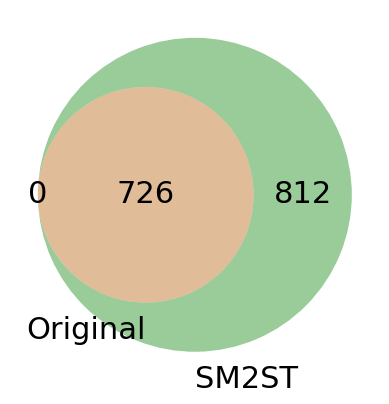

In [70]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Define two sets
set1 = ms_adata_v
set2 = adata_SMLED_v

# Draw a Venn diagram
venn = venn2([set1, set2], ('Original', 'SM2ST'))

# Set the display of the intersection and difference counts of the labels
venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')
# Set the font size of intersection and difference set labels
venn.get_label_by_id('100').set_fontsize(22)
venn.get_label_by_id('010').set_fontsize(22)
venn.get_label_by_id('110').set_fontsize(22)

# Set the font size of the collection labels
venn.get_label_by_id('A').set_fontsize(22) 
venn.get_label_by_id('B').set_fontsize(22) 

plt.show()

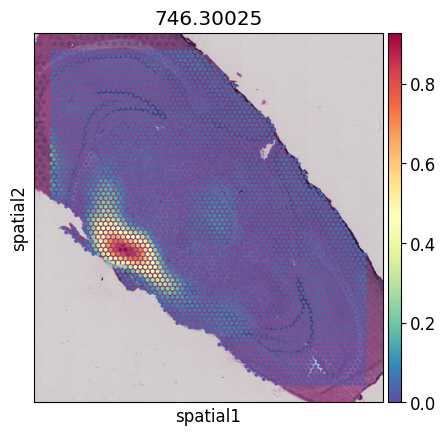

In [73]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['746.30025'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

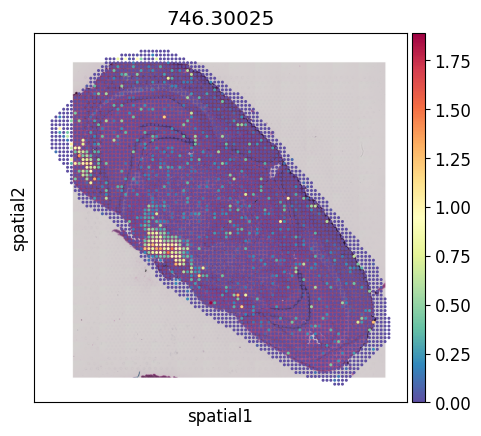

In [74]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['746.30025'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

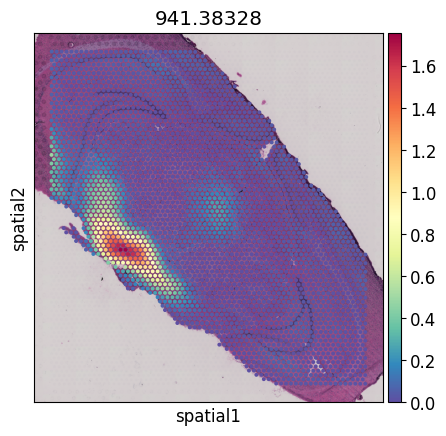

In [77]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['941.38328'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

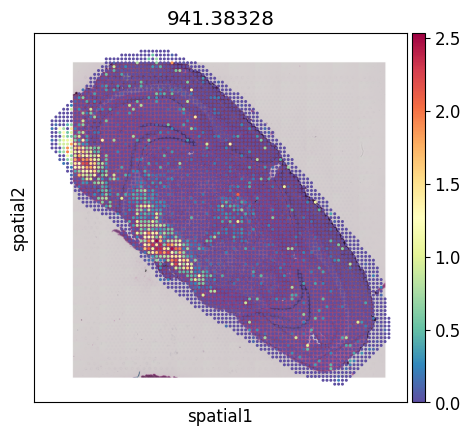

In [78]:
sc.pl.spatial(ms_adata, 
              img_key="hires", 
              color=['941.38328'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.05,
              spot_size=None,
              bw=False, 
              alpha_img=1)

In [79]:
ms_adata_va = ms_adata[:,list(ms_adata_v)]
adata_SMLED_va = adata_SMLED[:,list(ms_adata_v)]
ms_column_sums = np.sum(ms_adata_va.X.A, axis=0)

ms_m = ms_adata.X.A.shape[0]
ms_column_means = ms_column_sums / ms_m
SMLED_column_sums = np.sum(adata_SMLED_va.X.A, axis=0)

SMLED_m = ms_adata.X.A.shape[0]
SMLED_column_means = SMLED_column_sums / SMLED_m

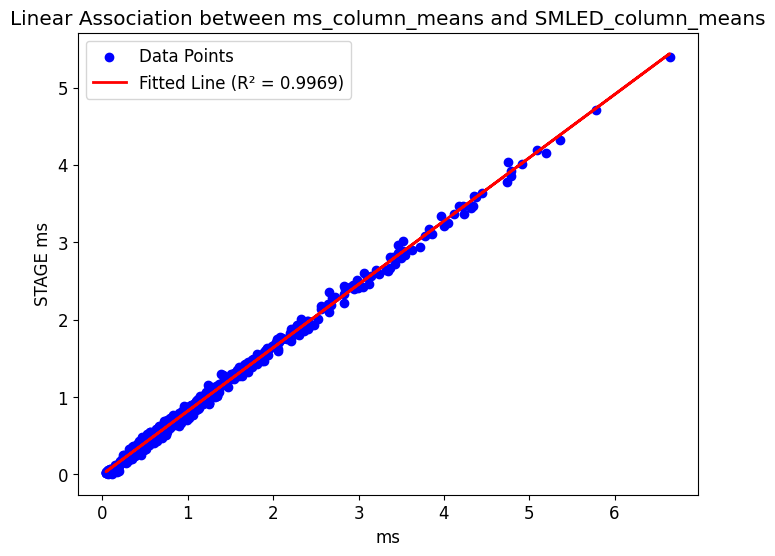

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 假设 ms_column_means 和 SMLED_column_means 是两个 NumPy 数组
# 如果不是 NumPy 数组，可以使用 np.array() 进行转换

# 计算线性回归
X = ms_column_means.reshape(-1, 1)  # 将 ms_column_means 转换为列向量
y = SMLED_column_means

# 创建线性回归模型
model = LinearRegression()
model.fit(X, y)

# 预测值
y_pred = model.predict(X)

# 计算 R² 值
r2 = r2_score(y, y_pred)

# 绘制散点图和拟合曲线
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data Points')  # 原始数据点
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted Line (R² = {r2:.4f})')  # 拟合曲线
plt.xlabel('ms')
plt.ylabel('STAGE ms')
plt.title('Linear Association between ms_column_means and SMLED_column_means')
plt.legend()
# plt.grid(True)
plt.show()